In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import numba as nb

In [3]:
@nb.njit(parallel=True)
def burning_ship(real, imag, size, n_pixels=500, max_iterations=100):
    y_range = np.linspace(imag-size/2, imag+size/2, n_pixels)
    x_range = np.linspace(real-size/2, real+size/2, n_pixels)
    image_data = np.zeros((n_pixels, n_pixels), dtype=np.uint8)

    # Parallel for loop over y
    for j in nb.prange(len(y_range)):
        y = y_range[j]
        for i in range(len(x_range)):
            x = x_range[i]
            c = (x, y)
            z = (x, y)
            iter = 0

            while z[0] * z[0] + z[1] * z[1] <= 4 and iter < max_iterations:
                # Mandelbrot:
                # z = z^2 + c until |z| > 2 or max iterations
                # const real = z.real * z.real - z.imag * z.imag + c[0];
                # const imag = 2 * z.real * z.imag + c[1];
                # Burning Ship:
                # z = |Re(z)|^2 - |Im(z)|^2 + c
                real = z[0]*z[0] - z[1]*z[1] + c[0]
                imag = np.abs(2*z[0]*z[1]) + c[1]
                z = (real, imag)
                iter += 1
    
            image_data[j, i] = iter
    return image_data

In [4]:
real = 0.
imag = -0.5
size = 4
max_iterations = 100
n_pixels = 256

n_pixels_preparation = 500
y_range = np.linspace(imag-size/2, imag+size/2, n_pixels_preparation)
x_range = np.linspace(real-size/2, real+size/2, n_pixels_preparation)

## Generate training data

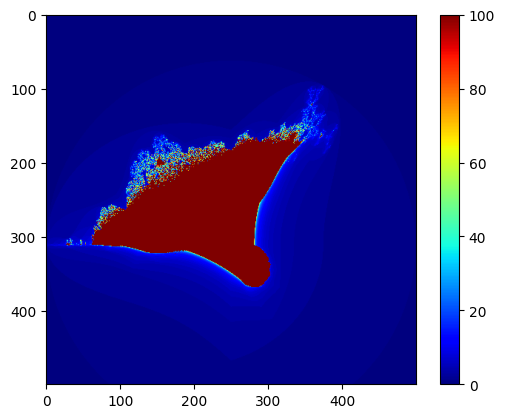

In [4]:
image = burning_ship(real, imag, size, n_pixels=n_pixels_preparation, max_iterations=max_iterations)
plt.imshow(image, cmap='jet')
plt.colorbar()

Number of points: 8145


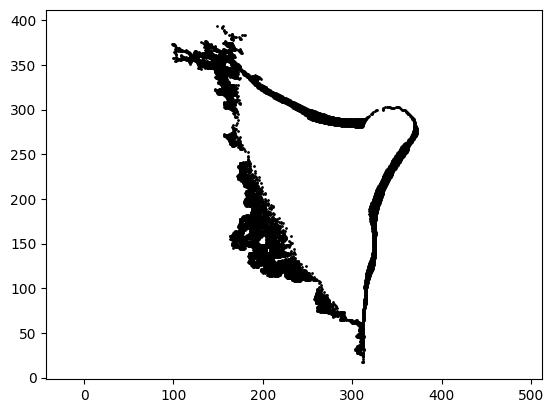

In [8]:
# Select all pixels that have a value between 10 and 99
image_mask = (10 <= image) & (image < 100)

plt.scatter(*np.where(image_mask), color='k', s=1)
plt.axis("equal")

print("Number of points:", np.sum(image_mask))
# This is a reasonable amount of points


In [5]:
@nb.njit(parallel=True)
def generate_training_data(mask, x_range, y_range, n_pixels, max_iterations):
    """
    Generate training data for the ML model that predicts the location of the fractal image.

    Parameters:
    - mask: A boolean array indicating which pixels to use.
    - x_range: The range of x values.
    - y_range: The range of y values.
    - n_pixels: Number of pixels in the zoomed image.
    - max_iterations: Maximum number of iterations for the fractal generation.

    Returns:
    - A list of zoomed images generated from the mask.
    """
    n_images = np.sum(mask)
    sizes = np.abs(np.random.normal(0.01, 0.01, size=n_images))
    real_values = np.zeros(n_images, dtype=np.float64)
    imag_values = np.zeros(n_images, dtype=np.float64)
    all_images = np.zeros((n_images, n_pixels, n_pixels), dtype=np.uint8)

    # Generate images with real and imag values extracted from the mask, and with a random size. The size should be taken at random from an exponential distribution with a mean of 0.01.
    for i, (y_idx, x_idx, size) in enumerate(zip(*np.where(mask), sizes)):
        real = x_range[x_idx]
        imag = y_range[y_idx]
        zoomed_image = burning_ship(real, imag, size, n_pixels=n_pixels, max_iterations=max_iterations)
        all_images[i] = zoomed_image
        real_values[i] = real
        imag_values[i] = imag

    return all_images, real_values, imag_values, sizes


In [ ]:
all_training_data, truth_real_values, truth_imag_values, truth_sizes = generate_training_data(image_mask, x_range, y_range, n_pixels=n_pixels, max_iterations=max_iterations)

In [51]:
# Write training data to a file
np.savez("training_data.npz", images=all_training_data, truth_real_values=truth_real_values, truth_imag_values=truth_imag_values, truth_sizes=truth_sizes)

## Prepare training data

In [ ]:
# Load the training data
data = np.load("training_data.npz")
all_training_data = torch.tensor(data["images"], dtype=torch.float32)

# Check if all the pixels are the same in images, and remove those images
mask = torch.any(all_training_data != all_training_data[:, 0:1, 0:1], dim=(1, 2))

# Normalize the training data to [0, 1]
all_training_data /= max_iterations

# Remove all images from the training data with < 100 pixels of values > 0
training_data = all_training_data[mask]

# Convert the truth values to tensors
truth_real_values = torch.tensor(data["truth_real_values"], dtype=torch.float32)[mask]
truth_imag_values = torch.tensor(data["truth_imag_values"], dtype=torch.float32)[mask]
truth_sizes = torch.tensor(data["truth_sizes"], dtype=torch.float32)[mask]

In [5]:
len(training_data), len(all_training_data), len(training_data) / len(all_training_data) # Fraction of training data that is used

(7913, 8145, 0.9715162676488643)

In [6]:
# Train-test split
train_size = int(0.9 * len(training_data))
all_idx = np.arange(len(training_data))
train_idx = np.random.choice(all_idx, size=train_size, replace=False)
test_val_idx = np.setdiff1d(all_idx, train_idx)
train_data = training_data[train_idx]

# 1/3 of the remaining data for validation, 2/3 for testing
validation_idx = np.random.choice(test_val_idx, size=len(test_val_idx)//3, replace=False)
validation_data = training_data[validation_idx]
test_idx = np.setdiff1d(test_val_idx, validation_idx)
test_data = training_data[test_idx]

truth_train_values = torch.stack((truth_real_values[train_idx], truth_imag_values[train_idx], truth_sizes[train_idx]), dim=1)
truth_validation_values = torch.stack((truth_real_values[validation_idx], truth_imag_values[validation_idx], truth_sizes[validation_idx]), dim=1)
truth_test_values = torch.stack((truth_real_values[test_idx], truth_imag_values[test_idx], truth_sizes[test_idx]), dim=1)

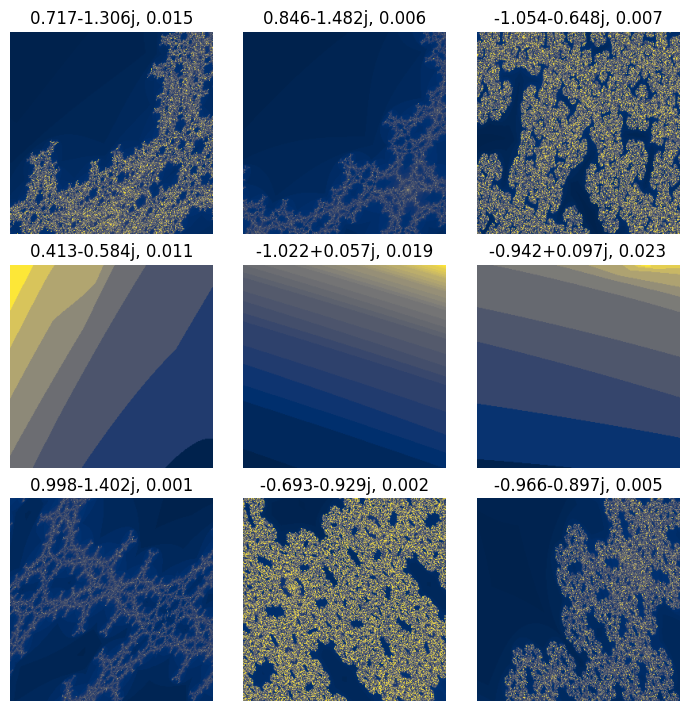

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(7, 7), layout='constrained')

for i, ax in enumerate(axs.flat):
    ax.imshow(train_data[i].numpy(), cmap='cividis')
    ax.axis("off")
    ax.set(title=f"{truth_train_values[i, 0]+truth_train_values[i, 1]*1j:.3f}, {truth_train_values[i, 2]:.3f}")

In [ ]:
import tqdm
# Create a CNN using PyTorch to train on the generated data
import torch.nn as nn
import torch.optim as optim

class FractalCNN(nn.Module):
    def __init__(self, n_pixels):
        """Initialize the FractalCNN model.
        This model consists of several convolutional layers followed by fully connected layers.
        The input is expected to be a 2D image with a single channel (grayscale).
        The output is a 3D vector representing the predicted location (real, imag, size) of the fractal image.
        """
        super(FractalCNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * (n_pixels // 4) * (n_pixels // 4), 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [13]:
# Initialize the model, loss function, and optimizer
model = FractalCNN(n_pixels)

training_loss = []
validation_loss = []

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
batch_size = 32
for epoch in range(num_epochs):
    model.train(True)
    epoch_train_loss = 0.0
    for i in tqdm.tqdm(range(0, len(train_data), batch_size)):
        inputs = train_data[i:i+batch_size].unsqueeze(1)  # Add channel dimension
        targets = truth_train_values[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs, targets)
        train_loss.backward()
        optimizer.step()
        
        epoch_train_loss += train_loss.item() * inputs.size(0)
    
    avg_train_loss = epoch_train_loss / len(train_data)
    training_loss.append(avg_train_loss)
    
    # Validation loss (once per epoch)
    model.eval()
    batch_validation_loss = []
    with torch.no_grad():
        for i in range(0, len(validation_data), batch_size):
            val_inputs = validation_data[i:i+batch_size].unsqueeze(1)
            val_targets = truth_validation_values[i:i+batch_size]
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_targets)
            batch_validation_loss.append(val_loss)
    validation_loss.append(np.mean(batch_validation_loss))
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}")
    # Save the model state after each epoch
    torch.save(model.state_dict(), f"fractal_cnn_epoch_{epoch+1}.pth")

100%|██████████| 223/223 [03:57<00:00,  1.07s/it]


Epoch [1/10], Train Loss: 0.7807, Val Loss: 0.2564


100%|██████████| 223/223 [03:54<00:00,  1.05s/it]


Epoch [2/10], Train Loss: 0.1831, Val Loss: 0.1527


100%|██████████| 223/223 [03:54<00:00,  1.05s/it]


...

Epoch [8/10], Train Loss: 0.0754, Val Loss: 0.2114


100%|██████████| 223/223 [04:21<00:00,  1.17s/it]


Epoch [9/10], Train Loss: 0.0612, Val Loss: 0.1178


100%|██████████| 223/223 [04:18<00:00,  1.16s/it]


Epoch [10/10], Train Loss: 0.0553, Val Loss: 0.1230


In [14]:
# Save the training and validation loss
np.savez("losses.npz", training_loss=training_loss, validation_loss=validation_loss)

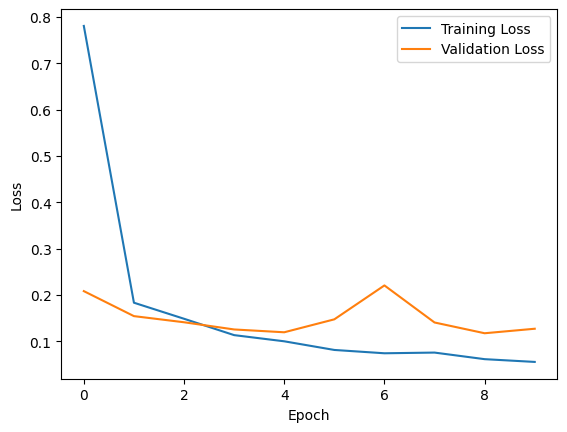

In [15]:
# Plot losses
fig, ax = plt.subplots()
ax.plot(training_loss, label='Training Loss')
ax.plot(validation_loss, label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

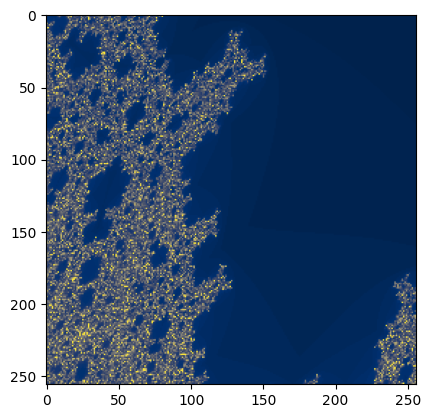

In [43]:
test_image = burning_ship(0.7, -1.306, 0.015, n_pixels=n_pixels, max_iterations=max_iterations)
plt.imshow(test_image, cmap="cividis")
test_image = torch.tensor(test_image, dtype=torch.float32) / max_iterations

In [52]:
loss_fn = nn.MSELoss()
# Load network and test on a new image
model = FractalCNN(n_pixels)
model.load_state_dict(torch.load("fractal_cnn_epoch_7.pth"))
model.eval()
with torch.no_grad():
    test_inputs = test_image.unsqueeze(0).unsqueeze(0)  # Add channel dimension
    test_outputs = model(test_inputs)
    print(test_outputs)
    test_loss = loss_fn(test_outputs, torch.tensor([[0.7, -1.306, 0.015]], dtype=torch.float32))
    print(f"Test Loss: {test_loss.item():.4f}")

tensor([[-0.7108, -0.6926,  0.0168]])
Test Loss: 0.7888


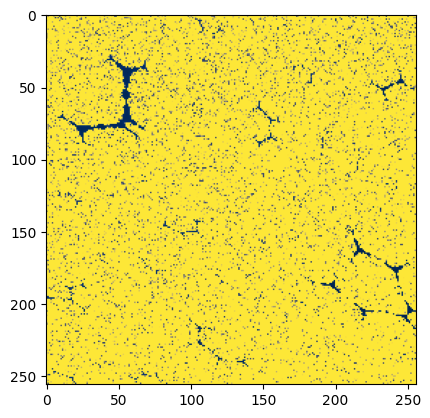

In [53]:
# Generate image from the model output
generated_image = burning_ship(*test_outputs[0].numpy(), n_pixels=n_pixels, max_iterations=max_iterations)

plt.imshow(generated_image, cmap="cividis")